# 06. 급증 구간 vs 기준 구간 감정 비교: 화장지 시험 (2026-10-07)

**목적**: 05 노트북(EOT-DETECT, Mistral-7B)이 뽑은 감정·원인 구절로, 화장지 검색이 급증한 2020년 3월(급증 구간)과 1년 전 같은 주(기준 구간)의 리뷰 감정이 어떻게 다른지 본다.

**입력** (`data/processed/eot_pilot/`): `eot_emotions.csv`(리뷰별 감정 0/1), `eot_triggers.csv`(감정별 원인 구절), `eot_raw.jsonl`(모델 원문 출력), `eot_pilot_sample.csv`(구간·평점)

**주의 (결과를 읽기 전에)**
1. **모델 결과는 아직 사람 라벨로 검증하지 않았다.** 세은·다빈의 50건 라벨이 오면 정확도(F1)를 계산해서, 이 비교를 얼마나 믿을지 정한다.
2. 구간마다 뽑힌 **상품이 다르다** (04 노트북: 상품 먼저 뽑기). 감정 차이에 "시기"와 "그 시기에 팔린 상품" 효과가 섞여 있다.
3. 감정 9개를 한꺼번에 검정하므로 **우연히 유의하게 나올 확률이 커진다.** Holm 방식으로 p값을 보정한 값도 같이 본다.

## 1. 준비

- `scipy`: Fisher 정확검정용. 처음 한 번만 설치한다.

In [1]:
%pip install -q scipy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

D = Path("../data/processed/eot_pilot")
emo  = pd.read_csv(D / "eot_emotions.csv", dtype={"review_id": str})
trig = pd.read_csv(D / "eot_triggers.csv", dtype={"review_id": str})
raw  = pd.read_json(D / "eot_raw.jsonl", lines=True, dtype={"review_id": str})
samp = pd.read_csv(D / "eot_pilot_sample.csv", dtype={"review_id": str})

EMOTIONS = ["Joy", "Trust", "Fear", "Surprise", "Sadness", "Disgust", "Anger", "Anticipation", "Neutral"]
KO = {"Joy": "기쁨", "Trust": "신뢰", "Fear": "두려움", "Surprise": "놀람", "Sadness": "슬픔",
      "Disgust": "혐오", "Anger": "분노", "Anticipation": "기대", "Neutral": "중립"}
N = emo.groupby("period").size()
print("리뷰 수:", N.to_dict(), "| JSON 읽은 방법:", emo["parse_how"].value_counts().to_dict())
print("trigger 검증:", trig["match"].value_counts().to_dict())

리뷰 수: {'baseline': 100, 'spike': 100} | JSON 읽은 방법: {'json': 177, 'regex': 23}
trigger 검증: {'exact': 297, 'none': 35, 'loose': 20}


## 2. 감정별 비율과 검정

- **비율**: 구간 리뷰 100건 중 그 감정이 한 번이라도 나온 리뷰의 비율. 한 리뷰에 감정이 여러 개일 수 있어서 합이 100%가 아니다.
- **Fisher 정확검정**: 두 구간의 비율이 우연으로 이 정도 차이 날 확률(p). 표본이 작아서(구간당 100건, 감정 대부분 10건 미만) 카이제곱 대신 정확검정을 쓴다.
- **Holm 보정 p**: 9개를 동시에 검정해서 생기는 우연 문제를 보정한 p. 0.05보다 작으면 보정 후에도 유의하다.
- **95% 신뢰구간**: Wilson 방식. 표본 비율이 0이나 1에 가까워도 범위가 이상해지지 않는다.

In [3]:
def wilson(k, n, z=1.96):
    p = k / n
    c = (p + z*z/(2*n)) / (1 + z*z/n)
    h = z * np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / (1 + z*z/n)
    return c - h, c + h

def holm(ps):
    order = np.argsort(ps); m = len(ps); adj = np.empty(m); run = 0
    for i, j in enumerate(order):
        run = max(run, (m - i) * ps[j]); adj[j] = min(1, run)
    return adj

def compare(df, emotions):
    rows = []
    for e in emotions:
        a, b = int(df.loc[df.period == "spike", e].sum()), int(df.loc[df.period == "baseline", e].sum())
        na, nb = int(N["spike"]), int(N["baseline"])
        p = fisher_exact([[a, na - a], [b, nb - b]])[1]
        rows.append({"감정": e, "한글": KO.get(e, e), "기준_건수": b, "급증_건수": a,
                     "기준_비율": b / nb, "급증_비율": a / na, "차이(%p)": 100 * (a / na - b / nb), "p": p})
    out = pd.DataFrame(rows)
    out["Holm_p"] = holm(out["p"].values)
    return out

res = compare(emo, EMOTIONS)
res.round({"기준_비율": 2, "급증_비율": 2, "차이(%p)": 1, "p": 4, "Holm_p": 4}).sort_values("차이(%p)", ascending=False)

,감정,한글,기준_건수,급증_건수,기준_비율,급증_비율,차이(%p),p,Holm_p
6,Anger,분노,5,18,0.05,0.18,13.0,0.0067,0.0605
5,Disgust,혐오,3,7,0.03,0.07,4.0,0.3311,1.0000
2,Fear,두려움,2,5,0.02,0.05,3.0,0.4448,1.0000
7,Anticipation,기대,4,7,0.04,0.07,3.0,0.5371,1.0000
4,Sadness,슬픔,6,7,0.06,0.07,1.0,1.0000,1.0000
8,Neutral,중립,7,5,0.07,0.05,-2.0,0.7673,1.0000
1,Trust,신뢰,4,2,0.04,0.02,-2.0,0.6827,1.0000
3,Surprise,놀람,4,1,0.04,0.01,-3.0,0.3687,1.0000
0,Joy,기쁨,51,43,0.51,0.43,-8.0,0.3213,1.0000


## 3. [그림] 구간별 감정 비율

점은 비율, 가로 막대는 95% 신뢰구간이다. 감정은 차이가 큰 순서로 정렬했다. 두 점의 신뢰구간이 거의 겹치지 않으면 차이가 우연이 아닐 가능성이 크다.

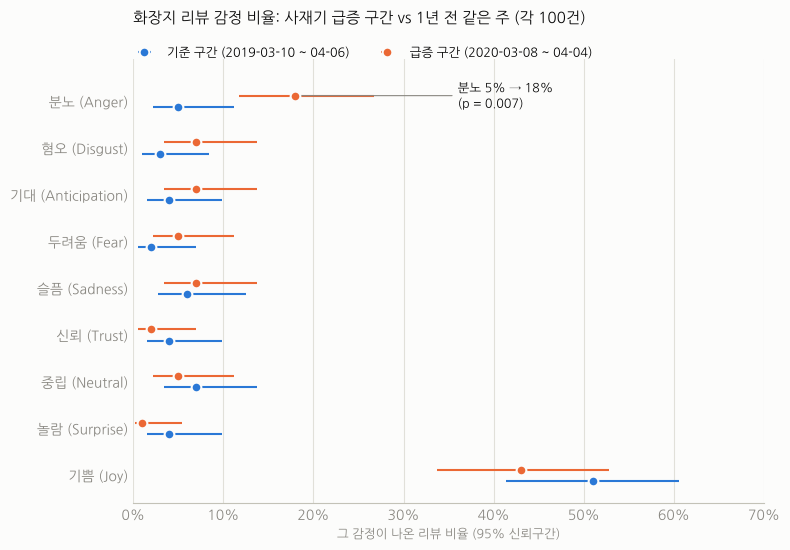

In [4]:
COL = {"baseline": "#2a78d6", "spike": "#eb6834"}          # 범주형 1·2번 색 (색각이상 검사 통과)
LAB = {"baseline": "기준 구간 (2019-03-10 ~ 04-06)", "spike": "급증 구간 (2020-03-08 ~ 04-04)"}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
from matplotlib import font_manager                         # 한글 글꼴: 윈도우 맑은 고딕 → 맥 → 나눔고딕 순
_have = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams["font.family"] = next((f for f in ["Malgun Gothic", "AppleGothic", "NanumGothic"] if f in _have), "DejaVu Sans")
plt.rcParams["axes.unicode_minus"] = False

r = res.sort_values("차이(%p)")
y = np.arange(len(r))
fig, ax = plt.subplots(figsize=(8, 5.6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
for k, dy in [("baseline", -0.12), ("spike", 0.12)]:
    cnt = r["기준_건수" if k == "baseline" else "급증_건수"].values
    lo, hi = zip(*[wilson(c, N[k]) for c in cnt])
    p = cnt / N[k]
    ax.errorbar(p, y + dy, xerr=[p - np.array(lo), np.array(hi) - p], fmt="o", ms=7, color=COL[k],
                ecolor=COL[k], elinewidth=1.5, capsize=0, label=LAB[k], zorder=3,
                markeredgecolor="#fcfcfb", markeredgewidth=1.5)
ax.set_yticks(y, [f"{row.한글} ({row.감정})" for row in r.itertuples()], color=INK)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlim(0, 0.7)
ax.grid(axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors=MUTED, length=0)
a = res.set_index("감정").loc["Anger"]
ax.annotate(f"분노 {a.기준_비율:.0%} → {a.급증_비율:.0%}\n(p = {a.p:.3f})", xy=(a.급증_비율, list(r.감정).index("Anger") + 0.12),
            xytext=(0.36, list(r.감정).index("Anger") + 0.12), color=INK, fontsize=9, va="center",
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.set_title("화장지 리뷰 감정 비율: 사재기 급증 구간 vs 1년 전 같은 주 (각 100건)", loc="left", color=INK, fontsize=11, pad=26)
ax.set_xlabel("그 감정이 나온 리뷰 비율 (95% 신뢰구간)", color=MUTED, fontsize=9)
ax.legend(loc="lower left", bbox_to_anchor=(-0.01, 0.99), borderaxespad=0, ncol=2, frameon=False, fontsize=9)
ax.set_ylim(-0.6, len(r) - 0.1)
fig.tight_layout()
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)
fig.savefig(FIG / "eot_pilot_emotion_by_period.png", dpi=200, facecolor=fig.get_facecolor())
plt.show()

## 4. 부정 감정을 묶어서 보기

감정 하나하나는 건수가 적어서 검정력이 약하다. 그래서 **분노·혐오·슬픔·두려움 중 하나라도 나온 리뷰**의 비율을 비교한다 (Plutchik의 부정 감정 4개).

In [5]:
NEG = ["Anger", "Disgust", "Sadness", "Fear"]
def neg_test(df, label):
    x = df[NEG].sum(axis=1) > 0
    a, b = int(x[df.period == "spike"].sum()), int(x[df.period == "baseline"].sum())
    p = fisher_exact([[a, N["spike"] - a], [b, N["baseline"] - b]])[1]
    return {"분석": label, "기준": f"{b}/{N['baseline']}", "급증": f"{a}/{N['spike']}", "p": round(p, 4)}
pd.DataFrame([neg_test(emo, "본 분석 (논문대로, 9개 밖 감정 버림)")])

,분석,기준,급증,p
0,"본 분석 (논문대로, 9개 밖 감정 버림)",14/100,35/100,0.0009


## 5. 보조 분석: "Disappointment(실망)"를 슬픔으로 셀 때

05 노트북에서 모델이 9개 밖 감정 이름을 45번 썼고, 그중 **"Disappointment"가 31번**이었다. 논문 방식대로면 버리지만, 실망은 Plutchik 이론에서 놀람+슬픔이 섞인 감정이고 우리 라벨링 지침도 "disappointed"를 Sadness로 정했다. 그래서 **실망을 슬픔으로 바꿔 한 번 더 계산**해서, 결론이 바뀌는지 본다 (민감도 분석).
- 원문 출력(`eot_raw.jsonl`)에서 감정 이름에 "disappoint"가 들어간 리뷰를 찾아 `Sadness = 1`로 바꾼다. trigger 검증은 따로 하지 않는다 (감정 유무만 보는 보조 분석).

In [6]:
dis_ids = set(raw.loc[raw["output"].str.contains(r'"emotion"\s*:\s*"[^"]*disappoint', case=False, regex=True), "review_id"])
emo2 = emo.copy()
emo2.loc[emo2["review_id"].isin(dis_ids), "Sadness"] = 1
print("Disappointment가 나온 리뷰:", emo[emo.review_id.isin(dis_ids)].groupby("period").size().to_dict())
res2 = compare(emo2, ["Sadness", "Anger"])
display(res2.round({"기준_비율": 2, "급증_비율": 2, "차이(%p)": 1, "p": 4, "Holm_p": 4}).drop(columns="Holm_p"))
pd.DataFrame([neg_test(emo, "본 분석"), neg_test(emo2, "보조 분석 (실망 → 슬픔)")])

Disappointment가 나온 리뷰: {'baseline': 19, 'spike': 14}


,감정,한글,기준_건수,급증_건수,기준_비율,급증_비율,차이(%p),p
0,Sadness,슬픔,25,21,0.25,0.21,-4.0,0.6145
1,Anger,분노,5,18,0.05,0.18,13.0,0.0067


,분석,기준,급증,p
0,본 분석,14/100,35/100,0.0009
1,보조 분석 (실망 → 슬픔),33/100,49/100,0.0308


## 6. 분노의 원인 구절 (급증 구간)

EOT의 장점은 감정이 **왜** 생겼는지 원문 구절로 보여 준다는 것이다. 급증 구간에서 분노로 분류된 리뷰의 trigger(본문에 글자 그대로 있는 것만)를 본다.

In [7]:
ang = (trig[(trig["match"] == "exact") & (trig["emotion"] == "Anger")]
       .merge(samp[["review_id", "period", "rating"]], on="review_id"))
print("분노 trigger 수:", ang.groupby("period").size().to_dict())
ang[ang.period == "spike"][["rating", "trigger"]].reset_index(drop=True)

분노 trigger 수: {'baseline': 12, 'spike': 35}


,rating,trigger
0,1.0,These reviews are lies!
1,1.0,giving it praise are BS
2,1.0,I thought these were double rolls so didn’t mind paying the ridiculous price of $61 dollars but after getting them...
3,1.0,will definitely not be buying again. Way too expensive!!
4,1.0,WASTE OF MONEY!
5,1.0,this one is 142 sheets per roll.
6,1.0,Feel ripped off
7,1.0,false info about it.
8,1.0,"Shame on you, you now qualify for the Hall of Shame."
9,1.0,very small roll and not soft at all.


## 7. 로그에 붙일 문장

아래 출력을 복사해 `logs/preprocessing_log.md` 맨 아래에 붙인다.

In [8]:
a = res.set_index("감정").loc["Anger"]; j = res.set_index("감정").loc["Joy"]
n1, n2 = neg_test(emo, ""), neg_test(emo2, "")
lines = [
    "### 2026-10-07 T4. 급증 vs 기준 구간 감정 비교: 화장지 시험 (김지우)",
    "노트북: `notebooks/06_eot_pilot_compare.ipynb`. 그림: `figures/eot_pilot_emotion_by_period.png`",
    "",
    f"- 분노(Anger): 기준 {a.기준_건수}/{N['baseline']} → 급증 {a.급증_건수}/{N['spike']} (Fisher p = {a.p:.4f}, 9개 동시 검정 Holm 보정 p = {a.Holm_p:.3f})",
    f"- 기쁨(Joy): 기준 {j.기준_건수}/{N['baseline']} → 급증 {j.급증_건수}/{N['spike']} (p = {j.p:.2f})",
    f"- 부정 감정(분노·혐오·슬픔·두려움 중 하나): 기준 {n1['기준']} → 급증 {n1['급증']} (p = {n1['p']}); 실망을 슬픔으로 셀 때 {n2['기준']} → {n2['급증']} (p = {n2['p']})",
    "- 급증 구간 분노 원인 구절: 가격 폭리(price gouging), 2겹이라더니 1겹(광고와 다름), 롤 크기·매수 부족",
    "- 한계: 모델 결과 사람 라벨 검증 전, 구간별 상품이 다름, 표본 구간당 100건",
]
print("\n".join(lines))

### 2026-10-07 T4. 급증 vs 기준 구간 감정 비교: 화장지 시험 (김지우)
노트북: `notebooks/06_eot_pilot_compare.ipynb`. 그림: `figures/eot_pilot_emotion_by_period.png`

- 분노(Anger): 기준 5/100 → 급증 18/100 (Fisher p = 0.0067, 9개 동시 검정 Holm 보정 p = 0.060)
- 기쁨(Joy): 기준 51/100 → 급증 43/100 (p = 0.32)
- 부정 감정(분노·혐오·슬픔·두려움 중 하나): 기준 14/100 → 급증 35/100 (p = 0.0009); 실망을 슬픔으로 셀 때 33/100 → 49/100 (p = 0.0308)
- 급증 구간 분노 원인 구절: 가격 폭리(price gouging), 2겹이라더니 1겹(광고와 다름), 롤 크기·매수 부족
- 한계: 모델 결과 사람 라벨 검증 전, 구간별 상품이 다름, 표본 구간당 100건
